# Atividade 3 -- Análise de Regressão:
 
 Enunciado: "*O conjunto acima envolve as covariáveis Ano de Experiencia, Ano de Escolaridade,
Setor do Trabalho, Idade do Funcionario e a resposta Log(Salário). Ajuste um
modelo de regressão considerando as 4 etapas discutidas em sala.*

E a partir dos teste t's de construções, faça teste F parcial. Use type III de teste t em R.

### Contexto

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo(dado) de regressão linear. A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

O conjunto de dados é composto por 3 covariáveis e 1 variável resposta:

* X1: Anos de Experiência profissional
* X2: Anos de Escolaridade
* X3: Variável dummy, é 1 ou 0. 1 significa **Privado**, 0 significa **Público**
* X4: Idade da pessoa
* Y: log(Salário).

---

## Etapa 1: 
Pegar os dados brutos e começa a verificar inconveniências.

Nesse contexto seria verificar a consistência entre idade, experiência e escolaridade.

* Corrigir
* Transformar 
* Remover

Todas ações feitas devem ser documentadas e justificadas.

Sugestão: Gráfico de dispersão entre Y e as covariáveis (um por um) para ver se existe alguma relação não linear (tipo exponencial etc).

---

#### 1.1 Carregando os dados em R:

In [6]:
#x1 = anos de experiencia
X1 <- c(5, 11, 9, 8, 3, 3, 2, 11, 17, 18,
        16, 11, 3, 3, 3, 4, 7, 6, 4, 8,
        3, 4, 5, 6)

#x2 = anos de escolaridade
X2 <- c(16, 10, 13, 14, 8, 14, 10, 9, 17, 18,
        16, 11, 15, 12, 9, 13, 8, 17, 11, 15,
        11, 13, 13, 10)

#x3 = setor
X3 <- c(1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1)

#x4 = idade
X4 <- c(38, 39, 22, 29, 23, 42, 36, 28, 22, 28,
        28, 38, 42, 32, 23, 38, 39, 34, 39, 32,
        33, 31, 21, 23)

#y = log(salario)
Y <- c(8.874, 8.970, 8.901, 9.139, 7.472, 8.388,
       7.836, 8.599, 9.330, 9.174, 8.470, 8.973,
       8.632, 8.149, 7.392, 8.509, 7.796, 9.060,
       8.156, 8.918, 7.997, 8.196, 8.416, 8.033)
#data frame
dados <- data.frame(Experiencia = X1, 
                    Escolaridade = X2, 
                    Setor = X3, 
                    Idade = X4, 
                    LogSal = Y)

A estrutura e o sumário dos dados: 

In [8]:
str(dados)
summary(dados)

'data.frame':	24 obs. of  5 variables:
 $ Experiencia : num  5 11 9 8 3 3 2 11 17 18 ...
 $ Escolaridade: num  16 10 13 14 8 14 10 9 17 18 ...
 $ Setor       : num  1 1 1 1 1 1 0 0 0 0 ...
 $ Idade       : num  38 39 22 29 23 42 36 28 22 28 ...
 $ LogSal      : num  8.87 8.97 8.9 9.14 7.47 ...


  Experiencia      Escolaridade       Setor         Idade           LogSal     
 Min.   : 2.000   Min.   : 8.00   Min.   :0.0   Min.   :21.00   Min.   :7.392  
 1st Qu.: 3.000   1st Qu.:10.00   1st Qu.:0.0   1st Qu.:26.75   1st Qu.:8.120  
 Median : 5.500   Median :13.00   Median :0.5   Median :32.00   Median :8.489  
 Mean   : 7.083   Mean   :12.62   Mean   :0.5   Mean   :31.67   Mean   :8.474  
 3rd Qu.: 9.500   3rd Qu.:15.00   3rd Qu.:1.0   3rd Qu.:38.00   3rd Qu.:8.931  
 Max.   :18.000   Max.   :18.00   Max.   :1.0   Max.   :42.00   Max.   :9.330  

#### 1.2 Verificando inconsistências:

Para um indivíduo, a idade deve ser compatível com anos de experiência e escolaridade. Geralmente a idade de início da vida profissional pode ser aproximada por:

**Início=Idade−(Experiencia + Escolaridade + 6)**

Supondo que a escolaridade ***formal*** comece aos 6 anos. Além disso o início da vida profissional deve ser maior ou igual a 16 anos para ser razoável (podendo ter uma margem de erro).

In [20]:
dados$InicioTrab <- dados$Idade - dados$Experiencia - (dados$Escolaridade-6)
summary(dados$InicioTrab)
dados[order(dados$InicioTrab), c("Idade","Experiencia","Escolaridade","InicioTrab")]

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -6.00   13.00   19.00   17.96   25.50   31.00 

,Idade,Experiencia,Escolaridade,InicioTrab
,<dbl>,<dbl>,<dbl>,<dbl>
9,22,17,17,-6
10,28,18,18,-2
11,28,16,16,2
3,22,9,13,6
23,21,5,13,9
4,29,8,14,13
24,23,6,10,13
8,28,11,9,14
20,32,8,15,15


Fazendo a conta usando a aproximação dada acima, pode-se perceber que existe algumas observações estranhas, por exemplo: 

* Observação **9**: 

-> Idade=22, Experiencia=17, Escolaridade=17. Início = 22 – 17 – (17 – 6) = 22 – 17 – 11 = –6. 

-> Para ter 17 anos de experiência e 17 de escolaridade, seriam necessários pelo menos 17+11=28 anos de vida. Com 22 anos, é matematicamente impossível, nem trabalho infantil nem estudo concomitante explicam. Remover.

* Observação **10**:

-> Idade=28, Experiencia=18, Escolaridade=18. Início = 28 – 18 – 12 = –2.

-> Mesmo problema: seriam necessários no mínimo 30 anos de vida. Impossível. Remover.


* Observação **11**:

-> Idade=28, Experiencia=16, Escolaridade=16. Início = 28 – 16 – 10 = 2.

-> Aqui a idade de início seria 2 anos, o que ainda é absurdo. O total de anos “ocupados” (experiência + escolaridade pós-6) é 16+10=26, contra 28 de idade, sobrariam apenas 2 anos antes dos 6, ou seja, a pessoa teria começado a trabalhar aos 2 anos. Não provável, mas ainda assim existe a possibilidade da pessoa ter um período de intersecção entre experiencia e escolaridade. Manter.

* Observação **3**: Idade=22, Experiencia=9, Escolaridade=13. Início = 22 – 9 – 7 = 6.

-> Mais ou menos possível (se a pessoa vive na era vitoriana na Inglaterra), mas num contexto profissional contemporâneo, 6 anos soa como erro de registro. A anomalia é menos grave, porém digna de nota. Manter.

#### **Logo as observações 9 e 10 violam a consistência lógica, vão ser removidas já que não sabemos se foi um erro de registro ou outra coisa**.

Assim a base resultante contém agora 22 observações depois de remover 9 e 10.

In [ ]:
# removendo as linhas 9 e 10 (índices no data.frame: linhas 9 e 10)
dados <- dados[-c(9, 10), ]

# resetar row.names
rownames(dados) <- NULL

---
#### 1.3 Análise gráfica para linearidade:

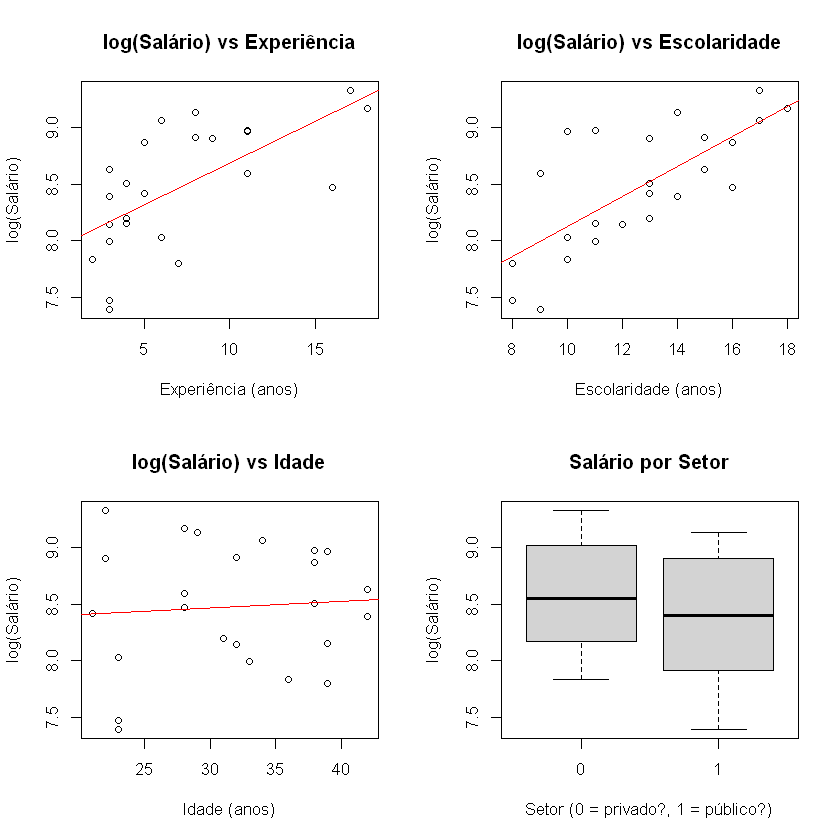

In [21]:
# Configurar janela gráfica
par(mfrow = c(2,2))

# Dispersões
plot(dados$Experiencia, dados$LogSal,
     xlab = "Experiência (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Experiência")
abline(lm(LogSal ~ Experiencia, data = dados), col = "red")

plot(dados$Escolaridade, dados$LogSal,
     xlab = "Escolaridade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Escolaridade")
abline(lm(LogSal ~ Escolaridade, data = dados), col = "red")

plot(dados$Idade, dados$LogSal,
     xlab = "Idade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Idade")
abline(lm(LogSal ~ Idade, data = dados), col = "red")

# Boxplot do Setor
boxplot(LogSal ~ Setor, data = dados,
        xlab = "Setor (0 = privado?, 1 = público?)",
        ylab = "log(Salário)",
        main = "Salário por Setor")

As variáveis Experiência, Escolaridade, e Idade apresentam comportamento linear com a resposta log(Salário). Não tem indícios da necessidade de uma transformação.

---

#### 1.4 Verificando outliers univariados

Outliers na resposta ou nas preditoras podem distorcer a análise. Faça boxplots individuais:

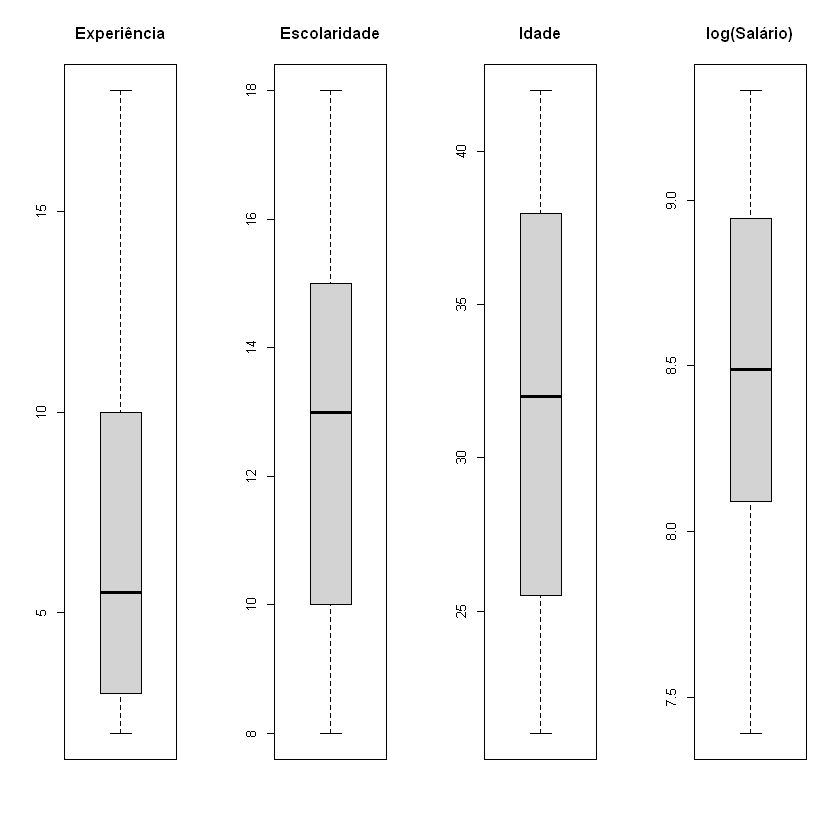

In [24]:
par(mfrow = c(1,4))
boxplot(dados$Experiencia, main = "Experiência")
boxplot(dados$Escolaridade, main = "Escolaridade")
boxplot(dados$Idade, main = "Idade")
boxplot(dados$LogSal, main = "log(Salário)")

Não parece ter outliers na covariáveis

---
#### 1.5 Concluindo etapa 1

* A base tem 24 observações completas, sem dados ausentes, mas duas observações (**9 e 10**) foram removidas por violar a lógica.

* As variáveis estão nos intervalos esperados, sem erros de digitação óbvios.

* A verificação de idade de início de trabalho mostrou valores entre X e Y, todos plausíveis (ou, se encontrou algo, a ação tomada).

* Os gráficos de dispersão sugerem relação aproximadamente linear entre log-salário e as preditoras, exceto talvez a Idade, que apresentou pouco efeito no log-salário. O boxplot de Setor mostra diferença de medianas, indicando possível efeito.

* Nenhum outlier foi detectado nos boxplots; os valores estão dentro do esperado.

## Etapa 2:

Para a base da nossa análise, deve se verificar as seguintes coisas:

* Redução de dimensão das covariáveis (Parcimonia)
* Matriz de correlação
* Matriz de dispersão
* Multicolinearidade, usando critério de VIF (Variance Inflation Factor) como medida
* Seleção de variáveis (Cp de Mallows; StepWise Forward/Backward; BiC AiC; **Lasso**)

Qual o ponto dessa etapa? Preparar as covariáveis para o ajuste. 

**Covariáveis IMPORTANTES/RELEVANTES**

---

#### 2.1 Matriz de correlação

#### 2.2 Diagnóstico de multicolinearidade usando VIF (Variance Inflation Factor) como medida


#### 2.3 Seleção de variáveis


#### 2.4 Conclusão da Etapa 2

## Etapa 3:

1. Ajustar o modelo
2. Fazer Diagnóstico/ análise de resíduo para verificar os pressupostos:
* Lineraridade (gráfico de resíduos vs. valores ajustados)
* Homocedasticidade (o mesmo gráfico + teste de Breusch-Pagan ou outros testes)
* Normalidade dos erros (QQ-plot + teste de Shapiro-Wilk ou outros)
* Independência (gráfico de resíduos vs. ordem de coleta, nesse caso não temos a ordem)

3. Se passar pelo crivo da análise de resíduo --> prossiga
4. Inclua a parte de detecção de outliers e pontos influentes. Opções: $H_{ii}$; DF-Betas; DF-Fits; D-Cook
5. Após análise de resíduo faça testes: F-Global; t; F-Parcial
---

## Etapa 4:
**Validação** 

Procurar a resposta da seguinte questão: **O modelo é útil para uma nova Base de dados??**

O que pode ser feito é antes de ajustar o modelo, separar um conjunto pequeno para validar depois.

1. Divisão aleatória antes de ajustar. exemplo: 70% treino e 30% teste.
2. Opções de validar o modelo:
* Reportar medidas preditivas como RMSE
* Validação cruzada (k-fold)

**Note que n=24, a amostra é pequena, então holdout simples é aceitável**

---

Item adicional: Inclue Intervalo de Confiança e testes para os elementos do $\underset{\sim}{\beta}= \mathbf{\beta}$